# Face Mask Detection — Model Trainer
**Role 4 — Ghada**  
Model: MobileNetV2 Transfer Learning | Framework: PyTorch



## 📦 Step 1 — Mount Drive & Extract Dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os


ZIP_PATH  = "/content/drive/MyDrive/data.zip"
DATA_ROOT = "/content/data/data"

if not os.path.exists(DATA_ROOT):
    print('📦 Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_ROOT)
    print('✅ Done!')

for root, dirs, files in os.walk(DATA_ROOT):
    level = root.replace(DATA_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if files:
        print(f'{indent}  → {len(files)} files')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data/
  data/
    Train/
      WithMask/
        → 4982 files
      WithoutMask/
        → 4983 files
    Validation/
      WithMask/
        → 398 files
      WithoutMask/
        → 400 files
    Test/
      WithMask/
        → 482 files
      WithoutMask/
        → 506 files


##  Step 2 — Imports & Config

In [ ]:
import time, copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms


DATA_DIR = "/content/data/data/data"
BATCH_SIZE   = 32
NUM_EPOCHS   = 20
LR_HEAD      = 1e-3
LR_FINETUNE  = 1e-4   
PATIENCE     = 4
NUM_CLASSES  = 2
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH    = "/content/drive/MyDrive/mask_detector.pth"
CURVES_PATH  = "/content/drive/MyDrive/training_curves.png"

print(f'🖥️  Device : {DEVICE}')
print(f'📁 Data   : {DATA_DIR}')
print(f'💾 Save to: {SAVE_PATH}')

🖥️  Device : cuda
📁 Data   : /content/data/data/data
💾 Save to: /content/drive/MyDrive/mask_detector.pth


##  Step 3 — Data Transforms & Loaders


In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Datasets
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'Train'),      transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'Validation'), transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'Test'),       transform=val_test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASS_NAMES = train_dataset.classes
print(f'Classes      : {CLASS_NAMES}')
print(f'Train size   : {len(train_dataset)}')
print(f'Val size     : {len(val_dataset)}')
print(f'Test size    : {len(test_dataset)}')
print(f'Train batches: {len(train_loader)}')

Classes      : ['WithMask', 'WithoutMask']
Train size   : 9965
Val size     : 798
Test size    : 988
Train batches: 312


##  Step 4 — Build Model (MobileNetV2)



In [ ]:
def build_model(num_classes=2):
    
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Freeze base layers to preserve ImageNet pretrained weights
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )

    return model.to(DEVICE)

model = build_model(NUM_CLASSES)

total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 126MB/s]


Total params    : 2,552,322
Trainable params: 328,450  (12.9%)


##  Step 5 — Training Loop (مع Early Stopping)

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion,
                num_epochs, patience, phase_name):
    """
    Training loop with early stopping.
    Returns: history dict + best model weights
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_loss  = float('inf')
    best_weights   = copy.deepcopy(model.state_dict())
    patience_count = 0  #  ==> to make the early stopping after 4 no improvement

    print(f'\n{'='*55}')
    print(f'  {phase_name}')
    print(f'{'='*55}')

    for epoch in range(num_epochs):
        start = time.time()

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            loader = train_loader if phase == 'train' else val_loader

            running_loss, running_correct = 0.0, 0

            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.argmax(dim=1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss    += loss.item() * inputs.size(0)
                running_correct += (preds == labels).sum().item()

            epoch_loss = running_loss    / len(loader.dataset)
            epoch_acc  = running_correct / len(loader.dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

        elapsed = time.time() - start
        print(f'Epoch {epoch+1:02d}/{num_epochs} | '
              f'Train Loss: {history["train_loss"][-1]:.4f}  Acc: {history["train_acc"][-1]:.4f} | '
              f'Val Loss: {history["val_loss"][-1]:.4f}  Acc: {history["val_acc"][-1]:.4f} | '
              f'⏱ {elapsed:.1f}s')

        # Early Stopping
        if history['val_loss'][-1] < best_val_loss:
            best_val_loss = history['val_loss'][-1]
            best_weights  = copy.deepcopy(model.state_dict())
            patience_count = 0
            print(f'  ✅ Val loss improved → saving best weights')
        else:
            patience_count += 1
            print(f'  ⚠️  No improvement ({patience_count}/{patience})')
            if patience_count >= patience:
                print(f'  🛑 Early stopping triggered at epoch {epoch+1}')
                break

    model.load_state_dict(best_weights)
    return model, history

## 🔥 Step 6 — Phase 1: Train Classifier Head (Base Frozen)

In [ ]:
# Responsible for training the Head only to distinguish between WithMask and WithoutMask
criterion = nn.CrossEntropyLoss()

optimizer_head = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD
)

model, history_phase1 = train_model(
    model, train_loader, val_loader,
    optimizer_head, criterion,
    num_epochs=10,
    patience=PATIENCE,
    phase_name='PHASE 1 — Classifier Head Training (Base Frozen)'
)


  PHASE 1 — Classifier Head Training (Base Frozen)
Epoch 01/10 | Train Loss: 0.1096  Acc: 0.9537 | Val Loss: 0.0213  Acc: 0.9937 | ⏱ 59.6s
  ✅ Val loss improved → saving best weights
Epoch 02/10 | Train Loss: 0.0696  Acc: 0.9752 | Val Loss: 0.0248  Acc: 0.9900 | ⏱ 55.7s
  ⚠️  No improvement (1/4)
Epoch 03/10 | Train Loss: 0.0689  Acc: 0.9739 | Val Loss: 0.0167  Acc: 0.9937 | ⏱ 56.1s
  ✅ Val loss improved → saving best weights
Epoch 04/10 | Train Loss: 0.0606  Acc: 0.9786 | Val Loss: 0.0183  Acc: 0.9912 | ⏱ 56.7s
  ⚠️  No improvement (1/4)
Epoch 05/10 | Train Loss: 0.0586  Acc: 0.9789 | Val Loss: 0.0182  Acc: 0.9912 | ⏱ 56.7s
  ⚠️  No improvement (2/4)
Epoch 06/10 | Train Loss: 0.0446  Acc: 0.9835 | Val Loss: 0.0127  Acc: 0.9925 | ⏱ 54.2s
  ✅ Val loss improved → saving best weights
Epoch 07/10 | Train Loss: 0.0487  Acc: 0.9818 | Val Loss: 0.0093  Acc: 0.9987 | ⏱ 56.1s
  ✅ Val loss improved → saving best weights
Epoch 08/10 | Train Loss: 0.0475  Acc: 0.9838 | Val Loss: 0.0097  Acc: 0.99

##  Step 7 — Phase 2: Fine-tune Top Layers

In [ ]:
for layer in list(model.features.children())[-3:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params after unfreeze: {trainable_ft:,}')

#smaller LR
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FINETUNE  #==> smaller to save the pretrained weights
)

model, history_phase2 = train_model(
    model, train_loader, val_loader,
    optimizer_ft, criterion,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    phase_name='PHASE 2 — Fine-tuning Top Layers'
)

Trainable params after unfreeze: 1,534,530

  PHASE 2 — Fine-tuning Top Layers
Epoch 01/20 | Train Loss: 0.0274  Acc: 0.9916 | Val Loss: 0.0064  Acc: 0.9987 | ⏱ 56.0s
  ✅ Val loss improved → saving best weights
Epoch 02/20 | Train Loss: 0.0155  Acc: 0.9944 | Val Loss: 0.0048  Acc: 0.9987 | ⏱ 56.5s
  ✅ Val loss improved → saving best weights
Epoch 03/20 | Train Loss: 0.0091  Acc: 0.9972 | Val Loss: 0.0099  Acc: 0.9950 | ⏱ 56.7s
  ⚠️  No improvement (1/4)
Epoch 04/20 | Train Loss: 0.0058  Acc: 0.9979 | Val Loss: 0.0020  Acc: 0.9987 | ⏱ 55.8s
  ✅ Val loss improved → saving best weights
Epoch 05/20 | Train Loss: 0.0070  Acc: 0.9981 | Val Loss: 0.0026  Acc: 0.9987 | ⏱ 55.2s
  ⚠️  No improvement (1/4)
Epoch 06/20 | Train Loss: 0.0074  Acc: 0.9972 | Val Loss: 0.0026  Acc: 0.9975 | ⏱ 56.4s
  ⚠️  No improvement (2/4)
Epoch 07/20 | Train Loss: 0.0060  Acc: 0.9981 | Val Loss: 0.0005  Acc: 1.0000 | ⏱ 55.9s
  ✅ Val loss improved → saving best weights
Epoch 08/20 | Train Loss: 0.0029  Acc: 0.9989 | 

##  Step 8 — Plot Training Curves

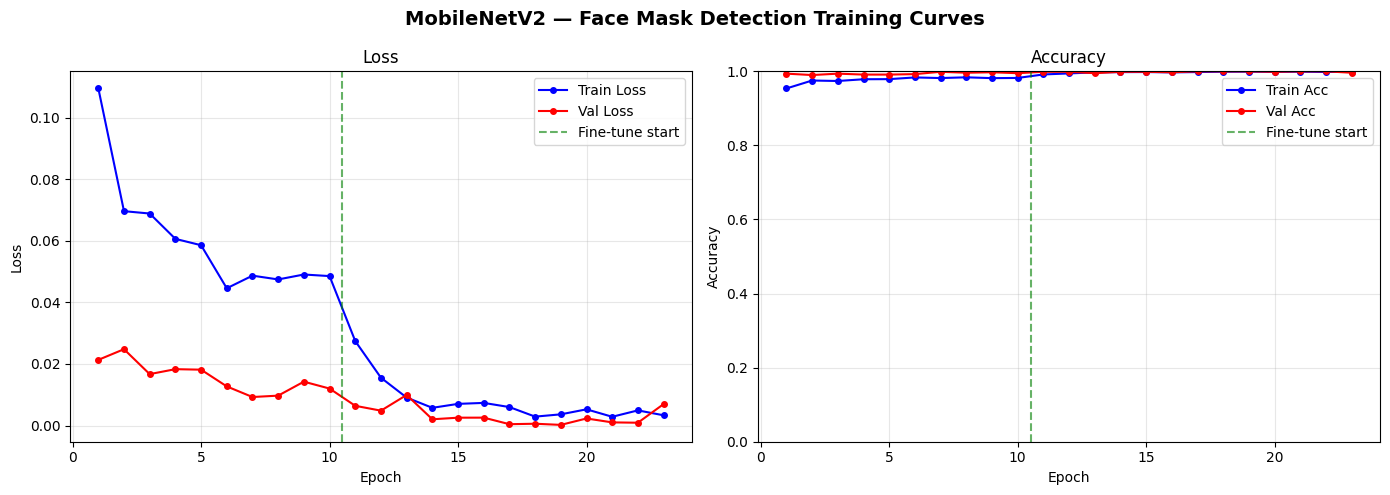

✅ Curves saved to: /content/drive/MyDrive/training_curves.png


In [ ]:
def merge_history(h1, h2):
    """Merge the history of each phase1 and phase 2"""
    return {k: h1[k] + h2[k] for k in h1}

history = merge_history(history_phase1, history_phase2)
epochs  = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 — Face Mask Detection Training Curves', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=4, label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train Acc')
axes[1].plot(epochs, history['val_acc'],   'r-o', markersize=4, label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)


p1_len = len(history_phase1['train_loss'])
for ax in axes:
    ax.axvline(x=p1_len + 0.5, color='green', linestyle='--', alpha=0.6, label='Fine-tune start')
    ax.legend()

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Curves saved to: {CURVES_PATH}')

##  Step 9 — Evaluate on Test Set

In [17]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        preds   = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

test_acc = correct / total
print(f'\n🎯 Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'   Correct: {correct}/{total}')

if test_acc >= 0.90:
    print('✅ Target achieved! (>90%)')
else:
    print('⚠️  Below 90% — consider more fine-tuning epochs')


🎯 Test Accuracy: 0.9990  (99.90%)
   Correct: 987/988
✅ Target achieved! (>90%)


##  Step 10 — Save Model

In [18]:
torch.save({
    'model_state_dict' : model.state_dict(),
    'class_names'      : CLASS_NAMES,
    'test_accuracy'    : test_acc,
    'architecture'     : 'MobileNetV2',
    'input_size'       : (224, 224),
    'normalization'    : {'mean': IMAGENET_MEAN, 'std': IMAGENET_STD}
}, SAVE_PATH)

print(f'✅ Model saved to: {SAVE_PATH}')
print(f'   Class names : {CLASS_NAMES}')
print(f'   Test Acc    : {test_acc:.4f}')
print('\n🎉 Done! Deliverables ready:')
print(f'   📦 mask_detector.pth   → {SAVE_PATH}')
print(f'   📈 training_curves.png → {CURVES_PATH}')

✅ Model saved to: /content/drive/MyDrive/mask_detector.pth
   Class names : ['WithMask', 'WithoutMask']
   Test Acc    : 0.9990

🎉 Done! Deliverables ready:
   📦 mask_detector.pth   → /content/drive/MyDrive/mask_detector.pth
   📈 training_curves.png → /content/drive/MyDrive/training_curves.png


              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       482
 WithoutMask       1.00      1.00      1.00       506

    accuracy                           1.00       988
   macro avg       1.00      1.00      1.00       988
weighted avg       1.00      1.00      1.00       988



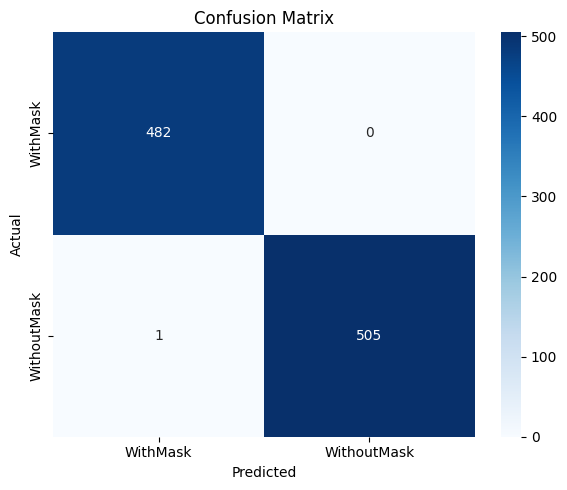

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# Track accuracy per epoch to confirm no overfitting occurred
print("Train acc per epoch:")
for i, acc in enumerate(history['train_acc']):
    print(f"  Epoch {i+1}: {acc:.4f}")

Train acc per epoch:
  Epoch 1: 0.9537
  Epoch 2: 0.9752
  Epoch 3: 0.9739
  Epoch 4: 0.9786
  Epoch 5: 0.9789
  Epoch 6: 0.9835
  Epoch 7: 0.9818
  Epoch 8: 0.9838
  Epoch 9: 0.9816
  Epoch 10: 0.9821
  Epoch 11: 0.9916
  Epoch 12: 0.9944
  Epoch 13: 0.9972
  Epoch 14: 0.9979
  Epoch 15: 0.9981
  Epoch 16: 0.9972
  Epoch 17: 0.9981
  Epoch 18: 0.9989
  Epoch 19: 0.9991
  Epoch 20: 0.9984
  Epoch 21: 0.9990
  Epoch 22: 0.9982
  Epoch 23: 0.9989


In [ ]:
import shutil

shutil.copy("/content/drive/MyDrive/mask_detector.pth", "/content/mask_detector.pth")
shutil.copy("/content/drive/MyDrive/training_curves.png", "/content/training_curves.png")
shutil.copy("/content/drive/MyDrive/confusion_matrix.png", "/content/confusion_matrix.png")

print("✅ Done!")

✅ Done!
